# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "../../"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


From https://github.com/SwRI-IDEA-Lab/butterflai
   2a6e8a0..37e9d0a  development/Ainsley_Helgerson -> origin/development/Ainsley_Helgerson
   1464bf1..7f2b80f  development/allisonc    -> origin/development/allisonc
   5f5a3b3..a7bf3af  development/andresmj    -> origin/development/andresmj
   68f6c73..e24548c  development/chienyu_sun -> origin/development/chienyu_sun
   a0f3bcc..2500f1d  development/claudiaholland -> origin/development/claudiaholland
   ce08637..a8be933  development/jalenw      -> origin/development/jalenw
   4337d93..c7d5b95  development/kyleV       -> origin/development/kyleV
   8b3a961..36fec12  development/li_loy      -> origin/development/li_loy
   62fac3e..e02c290  development/maxr        -> origin/development/maxr
   2a6e8a0..dd53970  development/myrak       -> origin/development/myrak
   30c2040..ae7c1a8  development/ovesa       -> origin/development/ovesa
   cf6258e..9465170  development/pmahlin     -> origin/development/pmahlin
 * [new branch]      developme

Already up to date.
  Installing from /Users/pplanet/butterflAI/butterflai/weeks/week_01/~butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : mps
   Seed     : 42


{'in_colab': False,
 'device': device(type='mps'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/var/folders/08/_3bxr1rj60bbzl2t7hgyzv1h0000gn/T/ipykernel_28096/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/var/folders/08/_3bxr1rj60bbzl2t7hgyzv1h0000gn/T/ipykernel_28096/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

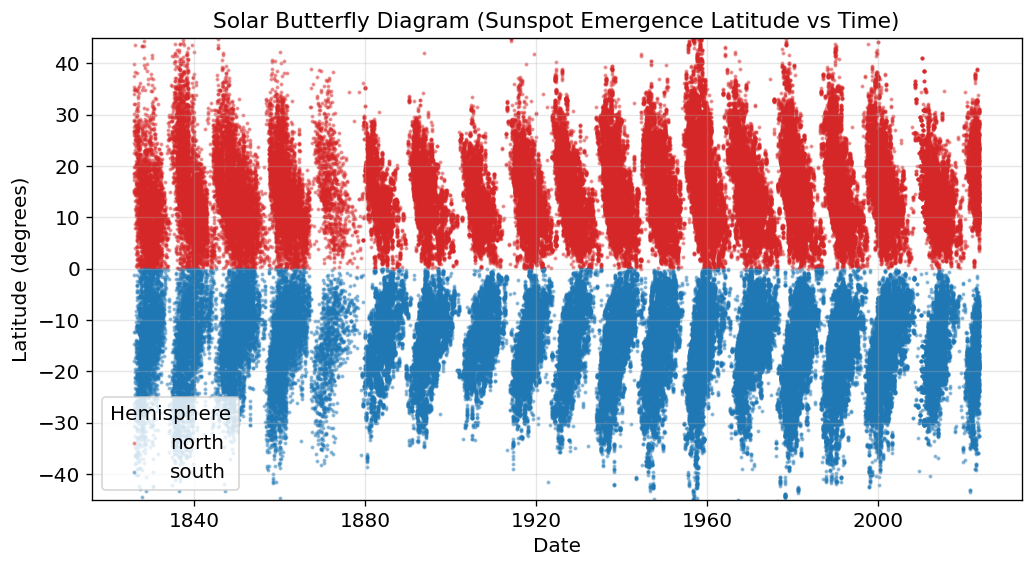

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


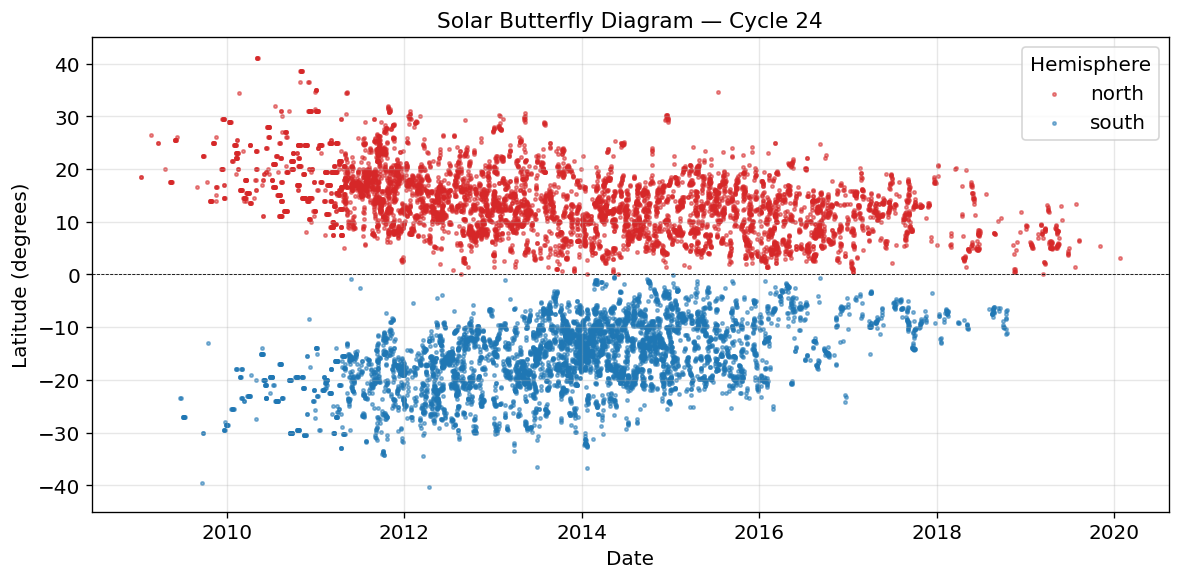

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [4]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/var/folders/08/_3bxr1rj60bbzl2t7hgyzv1h0000gn/T/ipykernel_28096/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


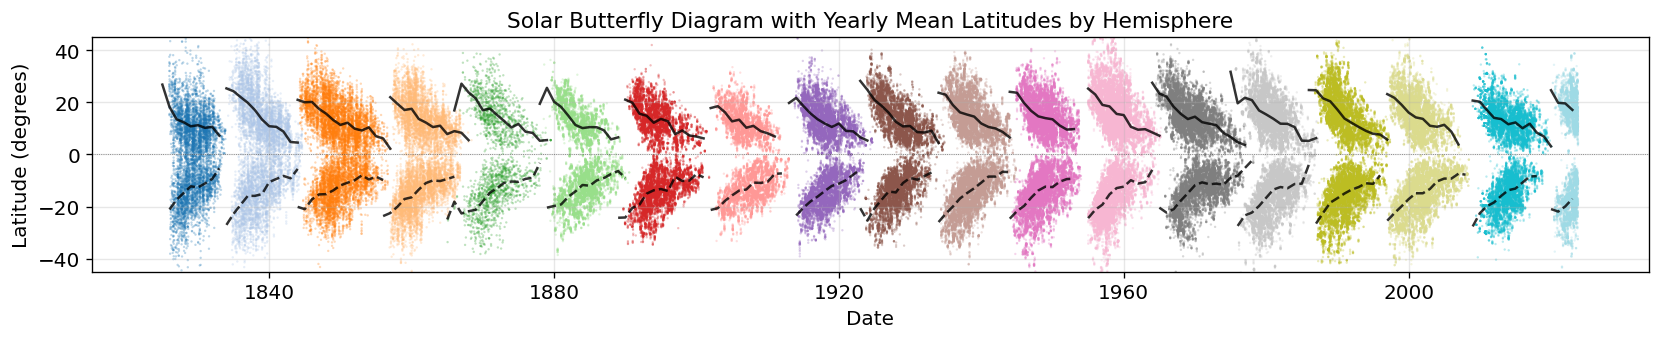

In [5]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]
    
    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
                linewidth=1.5, linestyle="-", alpha=0.8)
    
    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

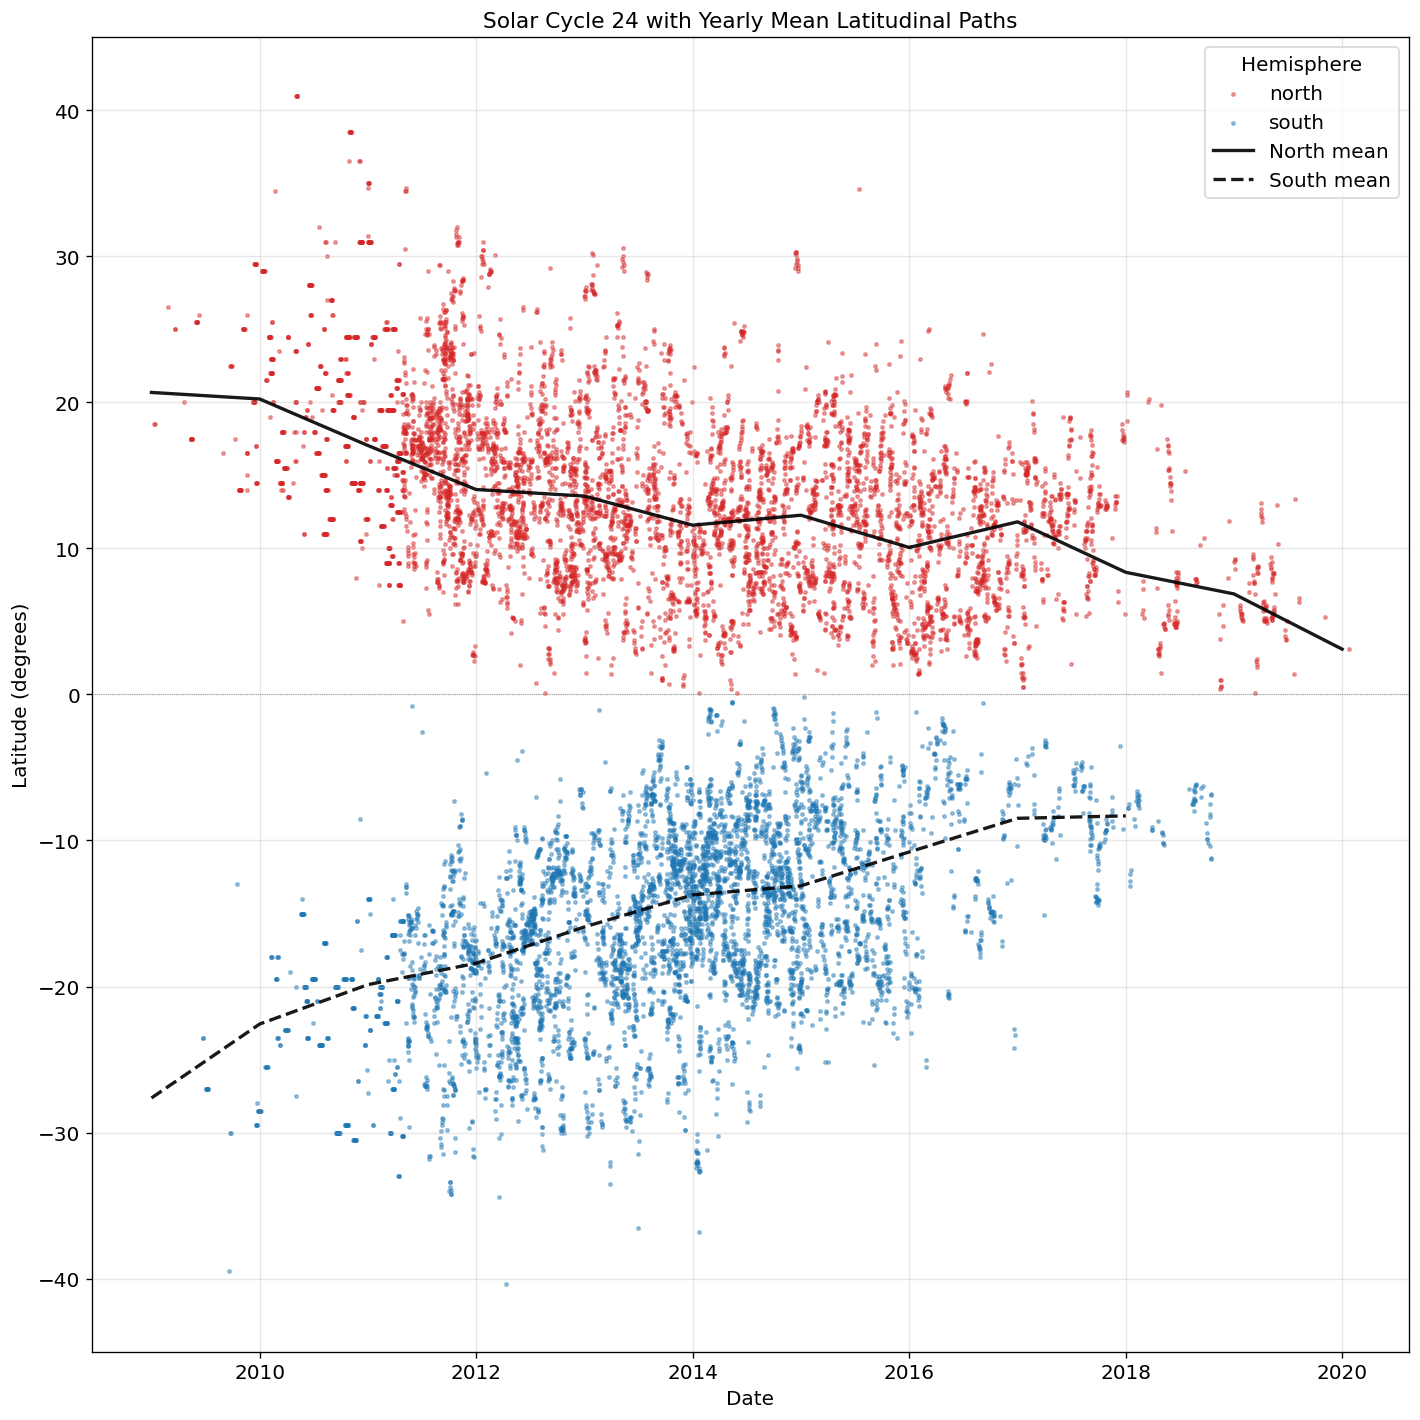

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [6]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


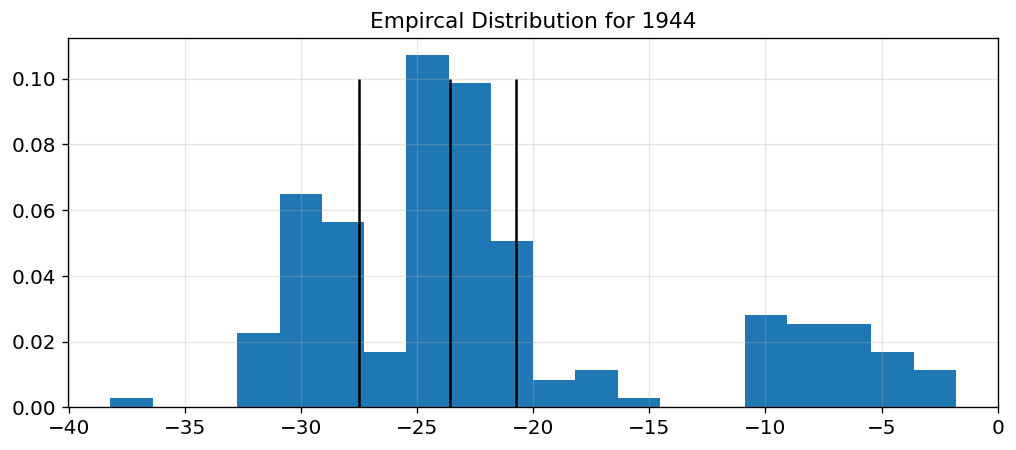

In [125]:
# Put your code for Task 6 here

# making a function makes Task 8 much easier
def plot_sunspot_hist(year, hemisphere, df=df, fig=None, ax=None, iqr_lines = True, **kwargs):

    if fig is None and ax is None:
        fig, ax = plt.subplots()

    df_annual = df[(df.year == year) & (df.hemisphere == hemisphere)].copy()

    ax.hist(df_annual["latitude"], density=True, bins=20, **kwargs)
    if(iqr_lines):
        ax.vlines([df_annual["latitude"].quantile(0.25), df_annual["latitude"].quantile(0.5), df_annual["latitude"].quantile(0.75)], ymin=0, ymax=0.1, colors="#000000")

    ax.set_title(f"Empircal Distribution for {year}")

plot_sunspot_hist(1944, "south")

IndexError: index 2 is out of bounds for axis 1 with size 2

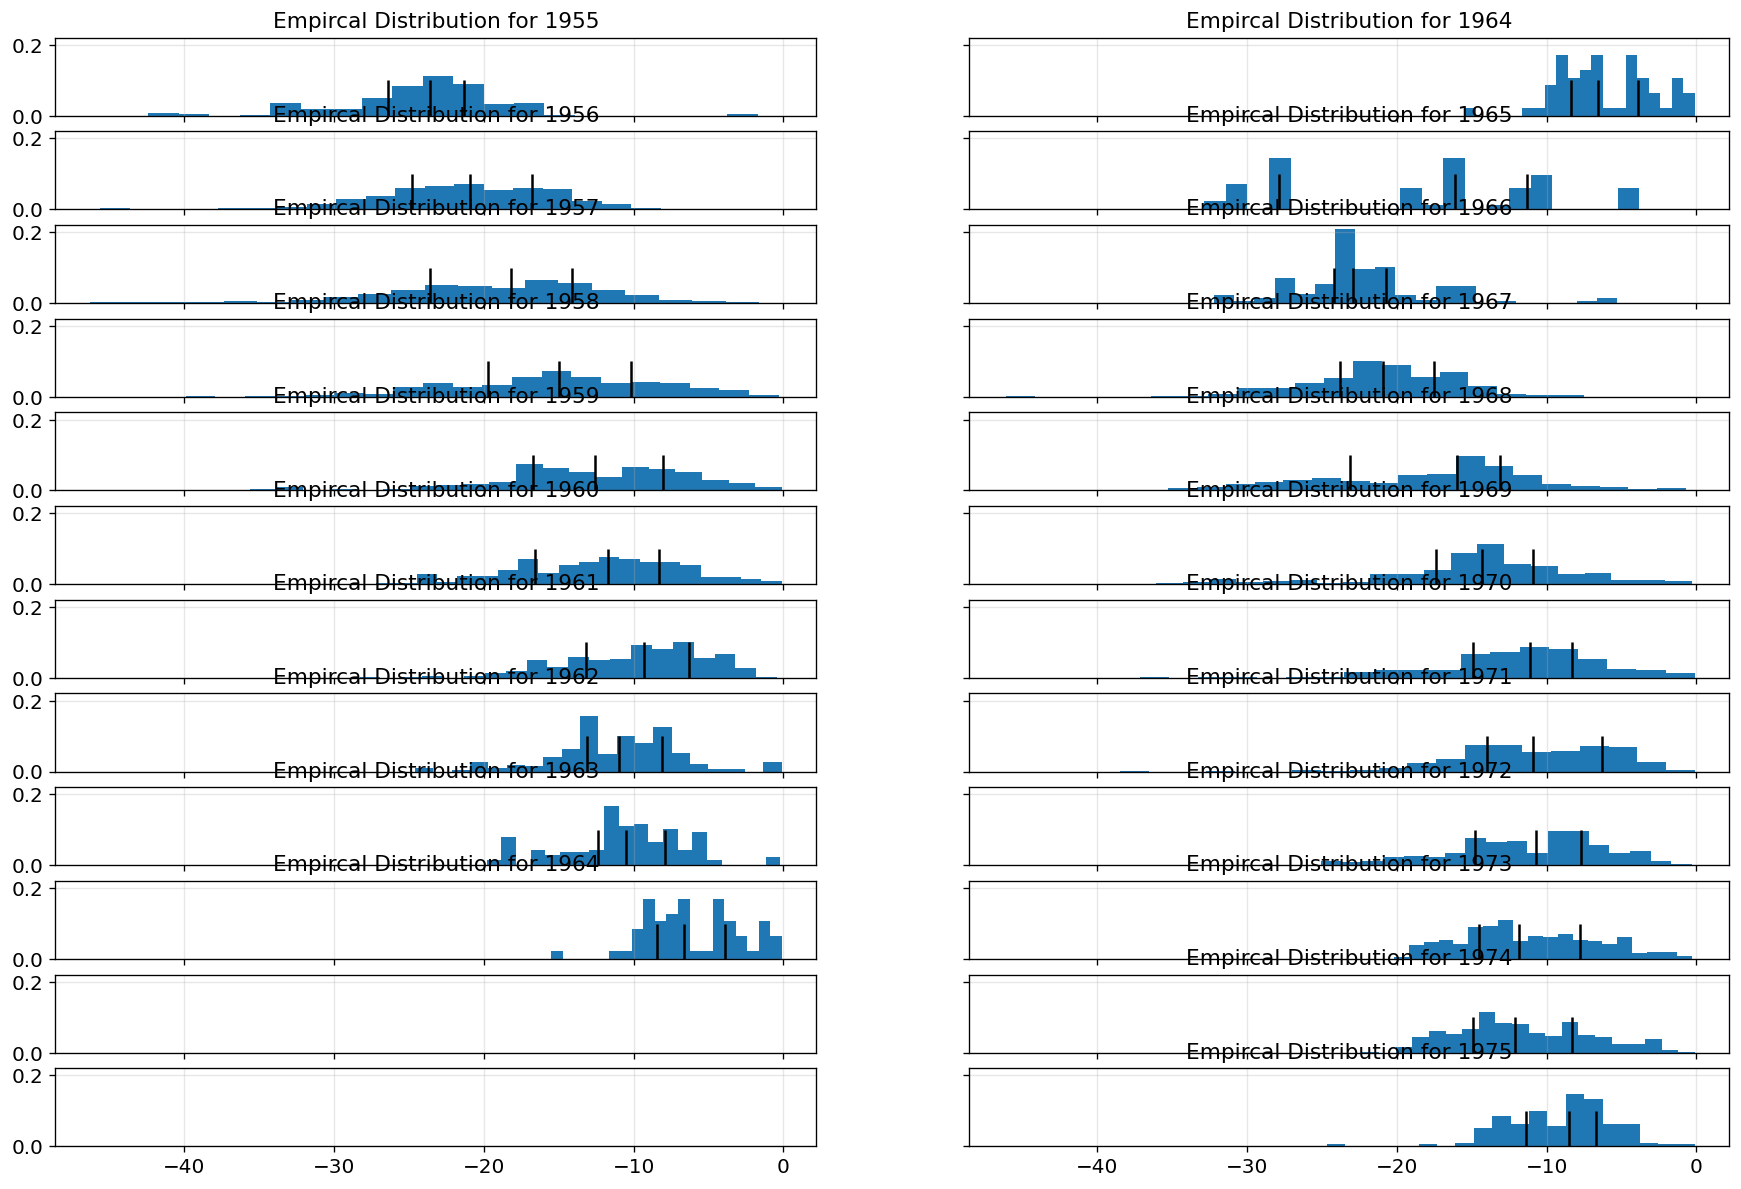

In [126]:
# to more easily compare their shapes side-by-side...

cycles = [19, 20]
hemisphere = "south"

years = pd.unique(df[df["CYCLE"].isin(cycles)]["year"])

fig, axes = plt.subplots(int(np.ceil(len(years)/len(cycles))), len(cycles), sharex=True, sharey=True, figsize=(18, 12))

current_cycle = cycles[0]
ref_i = 0
for i, year in enumerate(years):

    if df[df["year"] == year]["CYCLE"].max() != current_cycle:    
        plot_sunspot_hist(year, hemisphere, fig=fig, ax=axes[i-ref_i, current_cycle-cycles[0]])      
        ref_i = i
        current_cycle = current_cycle + 1
    plot_sunspot_hist(year, hemisphere, fig=fig, ax=axes[i-ref_i, current_cycle-cycles[0]])

*Something weird is going on in that plot (I think it has a lot of potential! but it definitely needs more refinement). Nevertheless, we definitely see a trend of sunspots not quite having symmetric distributions, and a trend for sunspots later in the cycle to be closer to the equator. The distribution is closer to symmetrical around the center of the solar cycle, and tends to spread out and skew at the edges of the solar cycles.*

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


In [110]:
# Put your code for Task 7 here
from scipy.stats import norm

# again, making a function here makes task 8 easier
def fit_sunspot_norm(year, hemisphere, df=df, **kwargs):

    df_annual = df[(df.year == year) & (df.hemisphere == hemisphere)].copy()

    return(norm.fit(df_annual["latitude"]))

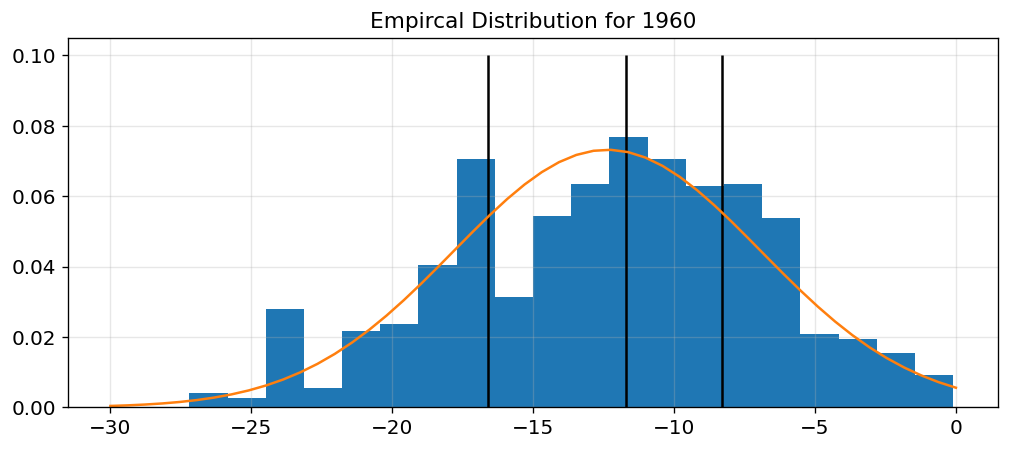

In [127]:
year = 1960
hemisphere = "south"

mu, sigma = fit_sunspot_norm(year, hemisphere)

x = np.linspace(-30, 0)

fig, ax = plt.subplots()

plot_sunspot_hist(year, hemisphere, fig=fig, ax=ax)
ax.plot(x, norm.pdf(x, mu, sigma))

*Here, the normal distribution fits pretty well. It captures the general shape of the distribution, but fails to capture some of the detail; here, I suspect there was one long-lasting sunspot region around -17 degrees which makes the distribution look a little strange. Overall, though, the median aligns well with the mean of the PDF, and the IQR lines are right about on opposite sides of the PDF. Mu should represent where the peak is, and sigma should represent some measure of the width of the distribution.*

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


Text(0.5, 1.0, 'Solar Cycle 20 Annual Distributions')

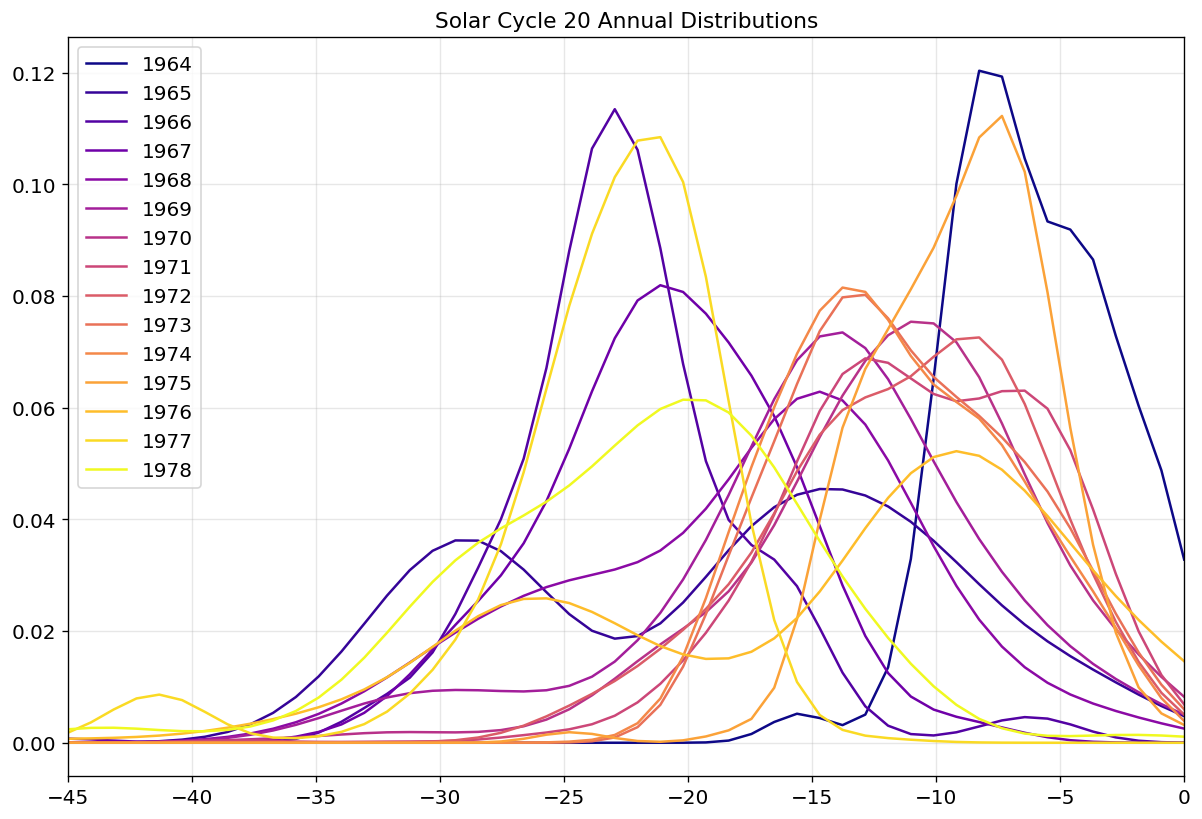

In [138]:
# Put your code for Task 8 here
from scipy.stats import gaussian_kde
import matplotlib.cm as cm

cycle = 20
hemisphere = "south"

years = pd.unique(df[df["CYCLE"] == cycle]["year"])
colors = cm.plasma(np.linspace(0,1, len(years)))

fig, ax = plt.subplots(figsize=(12,8))
x = np.linspace(-45, 0)

for year in years:
    df_annual = df[(df.year == year) & (df.hemisphere == hemisphere)].copy()
    kde = gaussian_kde(df_annual["latitude"], bw_method=0.4)
    ax.plot(x, kde.evaluate(x), label=str(year), color=colors[year-years[0]])

ax.legend()
ax.set_xlim(-45, 0)
ax.set_title(f"Solar Cycle {cycle} Annual Distributions")

*There is a distinct spread in distributions between years. The very first year likely includes some parts of the previous solar cycle, but otherwise, the distribution gets closer and broader over time.*